In [1]:
import spacy # text analysis
from spacy import displacy # tree plotting
import pandas as pd # data-frame manipulation
from tqdm.notebook import tqdm # progress bar
import matplotlib.pyplot as plt # plotting
import seaborn as sns # plotting
import nltk # natural language processing

nltk.download('punkt') # download the tokenizer

sns.set(context='paper', style='ticks', font_scale=1) # set the plot style

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/alexeykoshevoy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Let's load the spaCy model for the English language:

In [2]:
# !python3 -m spacy download en_core_web_sm

In [3]:
nlp = spacy.load("en_core_web_sm")

Let's also load the book corpus:

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/"
                                  "gastonstat/harry-potter-data/master/"
                                  "csv-data-file/harry_potter_books.csv")

In [5]:
df['text'][10]

'Dursleys had a small son called Dudley and in their opinion there'

In [6]:
# rebuild the full text for each book
books = (
    df.groupby("book", as_index=False)
      .agg(full_text=("text", " ".join))
)

# split into sentences
books["text"] = books["full_text"].apply(nltk.sent_tokenize)

# one sentence per row
harry_potter_corpus = (
    books[["text", "book"]]
    .explode("text")
    .reset_index(drop=True)
)

print(harry_potter_corpus.head())

                                                text  \
0  THE BOY WHO LIVED  Mr. and Mrs. Dursley, of nu...   
1  They were the last people you'd expect to be i...   
2  Mr. Dursley was the director of a firm called ...   
3  He was a big, beefy man with hardly any neck, ...   
4  Mrs. Dursley was thin and blonde and had nearl...   

                          book  
0  Book 1: Philosopher's Stone  
1  Book 1: Philosopher's Stone  
2  Book 1: Philosopher's Stone  
3  Book 1: Philosopher's Stone  
4  Book 1: Philosopher's Stone  


You can see that each row is storing one sentence and each sentence is annotated according to the book it is taken from.

In [7]:
harry_potter_corpus['text'][10]

'The Dursleys knew that the Potters had a small son, too, but they had never even seen him.'

Let's replace the book names with numbers. 

In [8]:
harry_potter_corpus['book'] = harry_potter_corpus['book']

In [9]:
harry_potter_corpus['book'] = harry_potter_corpus['book'].str.extract(r'(\d+)').astype(int)

How many books do we have?

In [10]:
harry_potter_corpus['book'].nunique()

7

## 0. Inspiration

The contents of this practical are heavily inspired by this [paper](https://www.pnas.org/doi/10.1073/pnas.2319514121), so if you want to know more about this kind of work you are encouraged to read it.

## 1. Syntax in spaCy

Besides from morphological analysis, spaCy can also be used to perfom syntactic analyses. For instance, you can get the syntactic category of a word, or its part-of-speech (POS).

Let's analyse the sentence "John saw a man with a telescope":


In [11]:
text = "John saw a man using a telescope"

Let's look at the POS and lemmas of the word-forms in this sentence. Notice that I can also get the dependency relationship that this word has with its head by using the `dep_` attribute.

In [12]:
for token in nlp(text):
    print(f'{token.text:{12}} {token.lemma_:{12}} {token.pos_:{12}} {token.dep_}')

John         John         PROPN        nsubj
saw          see          VERB         ROOT
a            a            DET          det
man          man          NOUN         dobj
using        use          VERB         acl
a            a            DET          det
telescope    telescope    NOUN         dobj


It's also possible to extract dependency relations between words. Here, we get the list of heads for each word. 

In [13]:
for token in nlp(text):
  print(token.text)
  print(list(token.ancestors))

John
[saw]
saw
[]
a
[man, saw]
man
[saw]
using
[man, saw]
a
[telescope, using, man, saw]
telescope
[using, man, saw]


Besides from this, we can also look at the overall dependency tree of the sentence:

In [14]:
displacy.render(nlp(text), style='dep', jupyter=True)

## 2. Which character has more agency?

Let's pick six of the main characters (Harry, Hermione, Ron, Neville, and Snape) and find all of the sentences where they are the subject (nsubj) of a verb. First, we will need to find all the sentences that contain the names of our characters. For simplicity, we will strart by only looking at book 1.

In [15]:
book_1 = harry_potter_corpus[harry_potter_corpus['book'] == 1]
book_1.shape

(4927, 2)

In [16]:
book_1['text'].values[10]

'The Dursleys knew that the Potters had a small son, too, but they had never even seen him.'

Let's find all the sentences with at least one of the six characters. We will be using the pandas `str` functionality to do this:

In [17]:
characters = ['Harry',
              'Hermione',
              'Ron',
              'Neville',
              'Snape',]

sents = book_1[book_1['text'].str.contains('|'.join(characters))]
sents.shape

(1797, 2)

Process these sentences using spaCy to identify cases where one of the characters functions as the nominal subject (nsubj) of a verb. For each sentence, parse it with spaCy and examine the tokens. When a token corresponds to a character and has the dependency label nsubj, retrieve the verb that governs this subject by examining the token’s ancestors in the dependency tree and selecting the governing verb.

Store the results in a list called subjs. Each element of this list should be a tuple of the form (character, verb, sentence_index). For example, given the sentence “Harry eats a pizza”, you should add the tuple ("Harry", "eat", 0) to subjs.

In addition, keep track of how many sentences mention each character at all. Store this information in a dictionary called counts_frec, where the keys are the character names and the values represent the number of sentences in which that character appears as a subject.

In [18]:
subjs = []
counts_frec = dict()

for i, sent in enumerate(tqdm(sents['text'].values)):
    
    doc = nlp(sent)

    for token in doc: 
        if token.text in characters:
            counts_frec[token.text] = counts_frec.get(token.text, 0) + 1

            if token.dep_ == 'nsubj':
                for ancestor in token.ancestors:
                    if ancestor.pos_ == "VERB":
                        subjs.append((token.text, ancestor.lemma_, i))

  0%|          | 0/1797 [00:00<?, ?it/s]

Let's look at the results:

In [19]:
subjs[:10]

[('Harry', 'survive', 6),
 ('Harry', 'wake', 19),
 ('Harry', 'hear', 20),
 ('Harry', 'say', 21),
 ('Harry', 'get', 23),
 ('Harry', 'look', 27),
 ('Harry', 'have', 28),
 ('Harry', 'have', 29),
 ('Harry', 'like', 30),
 ('Harry', 'turn', 31)]

Now let's convert this to a dataframe:

In [20]:
subjects_df = pd.DataFrame(subjs, columns=['subject', 'verb', 'sent'])
subjects_df.head(10)

,subject,verb,sent
0,Harry,survive,6
1,Harry,wake,19
2,Harry,hear,20
3,Harry,say,21
4,Harry,get,23
5,Harry,look,27
6,Harry,have,28
7,Harry,have,29
8,Harry,like,30
9,Harry,turn,31


Let's count the number of times each of the characters is a subject in a sentence. 

In [21]:
counts = subjects_df['subject'].value_counts()

Now we plot them:

In [22]:
counts

subject
Harry       1103
Ron          321
Hermione     171
Snape        162
Neville       65
Name: count, dtype: int64

While this plot is providing some information, it is a bit meaningless, since Hary appears the most in all of the sentences anyways, let's divide this number by the number of total appearances to get the percentage of `subjecthood`. 

For this, you would need to convert counts into a dataframe, and then combine it with the counts_frec dictionary to get the percentages.

In [23]:
counts_df = pd.DataFrame(counts).reset_index()

counts_df['count_freq'] = counts_df['subject'].apply(lambda x: counts_frec[x])
counts_df['percentage_nsubj'] = counts_df['count'] / counts_df['count_freq']

counts_df

,subject,count,count_freq,percentage_nsubj
0,Harry,1103,1324,0.833082
1,Ron,321,429,0.748252
2,Hermione,171,269,0.635688
3,Snape,162,172,0.941860
4,Neville,65,117,0.555556


Now plot the percentages of subjecthood against the total appearances. What does it tell you?

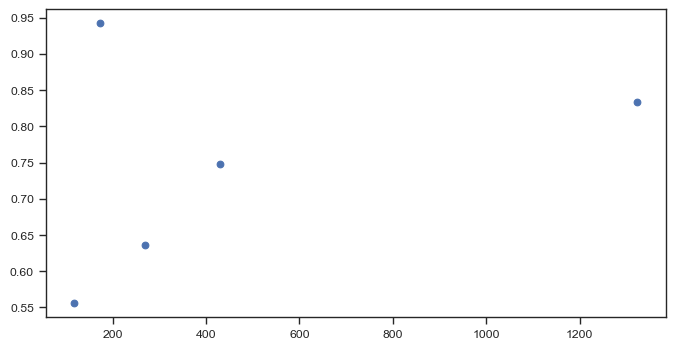

In [24]:
plt.figure(figsize=(8, 4))
plt.scatter(x=counts_df['count_freq'], y=counts_df['percentage_nsubj'])

Let's also plot the percentages of all characters, what this plot can tell you about the first book?

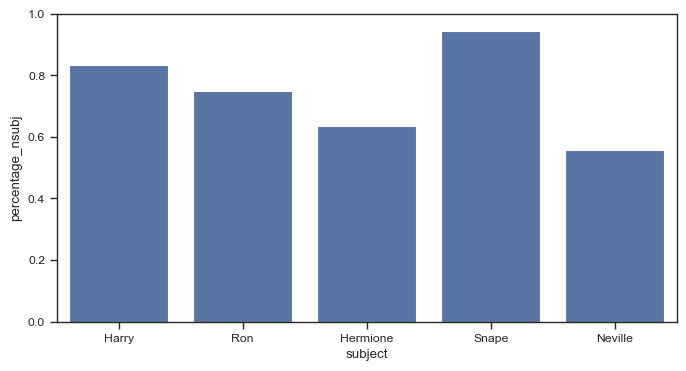

In [25]:
plt.figure(figsize=(8, 4))
sns.barplot(data=counts_df, x='subject', y='percentage_nsubj')
plt.ylim(0, 1)
plt.show()

As you can see from the `counts_df` database, we also stored the verbs corresponding to each of the three characters -- which verbs are the most frequently used with which character?

In [26]:
verb_count = subjects_df.groupby('subject')['verb'].value_counts().reset_index()

In [28]:
verb_count.head(10)

,subject,verb,count
0,Harry,say,177
1,Harry,look,36
2,Harry,have,34
3,Harry,see,33
4,Harry,think,33
5,Harry,feel,27
6,Harry,go,24
7,Harry,know,20
8,Harry,hear,18
9,Harry,tell,18


 For each character, plot the top 5 most frequent verbs that they are the subject of.

In [29]:
for character in characters:
    print(verb_count.query(f'subject == "{character}"')[0:4])

  subject  verb  count
0   Harry   say    177
1   Harry  look     36
2   Harry  have     34
3   Harry   see     33
      subject  verb  count
279  Hermione   say     48
280  Hermione  look      4
281  Hermione    do      3
282  Hermione  gasp      3
    subject    verb  count
422     Ron     say    117
423     Ron    look     10
424     Ron  mutter      8
425     Ron    have      7
     subject  verb  count
372  Neville   say      7
373  Neville  look      3
374  Neville   try      3
375  Neville   let      2
    subject verb  count
540   Snape  say     19
541   Snape   go      8
542   Snape  get      6
543   Snape  try      6


## 3. Agency surplus

The interesting thing about spaCy is that we can not only detect subjects, but arso objects, i.e. participants on which the action is directed.

For instance, in the sentence "John saw a man with a telescope", "a man" or "a man with a telescope" are objects of the verb "see", depending on the interpretation.

We can see this on the dependency tree, where the objects of a verb are usually labeled as labelled `dobj`:

In [30]:
displacy.render(nlp(text), style='dep', jupyter=True)

Let's modify our code from above to also record cases in which one of the characters is an object. For that, we will add a new list `objs`, in which we will store the verbs in which the corresponding character appears as `dobj`. 

You need to store the subjects and objects into two different lists, which will contain the tuples (character, verb, sentence_index) as before.

In [31]:
# find the sentences in which the character is nsubj, but also record the verb
subjs = []
objs = []

for sent in tqdm(sents['text'].values):
    doc = nlp(sent)

    for token in doc:
        if token.dep_ == 'nsubj' and token.text in characters:
            for ancestor in token.ancestors:
                if ancestor.pos_ == 'VERB':
                    subjs.append((token.text, ancestor.lemma_))

        if token.dep_ == 'dobj' and token.text in characters:
            for ancestor in token.ancestors:
                if ancestor.pos_ == 'VERB':
                    objs.append((token.text, ancestor.lemma_))

  0%|          | 0/1797 [00:00<?, ?it/s]

Now let's combine all of this into one dataframe:

In [32]:
# let's convert both lists to dataframes
subjs_df = pd.DataFrame(subjs, columns=['character', 'verb'])
objs_df = pd.DataFrame(objs, columns=['character', 'verb'])

## add columns with roles
subjs_df['role'] = 'subject'
objs_df['role'] = 'object'

# concatenate the dataframes
agency_df = pd.concat([subjs_df, objs_df])

agency_df.head(5)

,character,verb,role
0,Harry,survive,subject
1,Harry,wake,subject
2,Harry,hear,subject
3,Harry,say,subject
4,Harry,get,subject


Now we can compute the number of times that the characters were either subjects or objects, and we can convert these values to percentages according to the total number of sentences in which every character is either a subject or an object. Let's start by counting the number of times each character is a subject or an object:

In [33]:
character_summary = agency_df.groupby('character')['role'].value_counts().reset_index()
character_summary

,character,role,count
0,Harry,subject,1103
1,Harry,object,134
2,Hermione,subject,171
3,Hermione,object,14
4,Neville,subject,65
5,Neville,object,15
6,Ron,subject,321
7,Ron,object,46
8,Snape,subject,162
9,Snape,object,17


Now let's convert the counts into percentages by summing them for each character and then dividing each entry by this sum:

In [34]:
character_summary['percentage'] = character_summary.groupby('character')['count']\
    .transform(lambda x : x / x.sum())
character_summary.head(10)

,character,role,count,percentage
0,Harry,subject,1103,0.891673
1,Harry,object,134,0.108327
2,Hermione,subject,171,0.924324
3,Hermione,object,14,0.075676
4,Neville,subject,65,0.812500
5,Neville,object,15,0.187500
6,Ron,subject,321,0.874659
7,Ron,object,46,0.125341
8,Snape,subject,162,0.905028
9,Snape,object,17,0.094972


We can access the percetages of subjects and objects for each character by using indexes (0 -- subject, 1 -- object):

In [35]:
# subject percentage for Hermione
character_summary.query('character == "Hermione"')['percentage'].values[0]

0.9243243243243243

In [36]:
# object percentage for Hermione
character_summary.query('character == "Hermione"')['percentage'].values[1]

0.07567567567567568

Now compute the agency surplus by applying the following equation to each character:

$$\text{Agency surplus} = count(object) - count(subject)$$

If this value is positive, the character is more frequently and object, but if it's negative, the character is more likely to be a subject, i.e. an active participant.

Compute the agencty suprulus for each character and plot the results. Store it in the a_suprlus list, which should look like this: (character, surplus value). What does it tell you about the characters in the first book?

In [37]:
# subtract object - subject for each character
a_surplus = []

for c in characters:
    a_surplus.append((c, character_summary.query(f'character == "{c}"')['percentage'].values[1]\
                       - character_summary.query(f'character == "{c}"')['percentage'].values[0]))

We can also plot the surplus for each character:

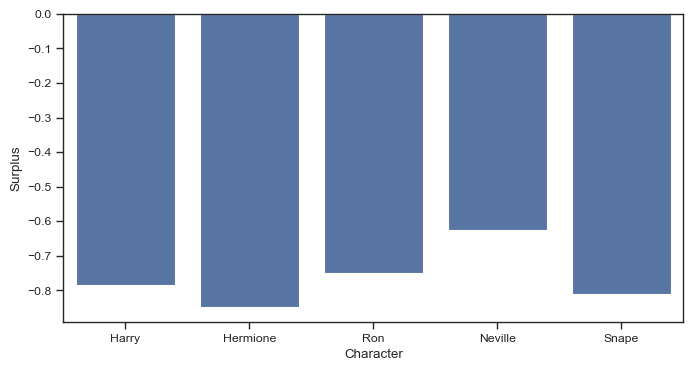

In [38]:
plt.figure(figsize=(8, 4))
sns.barplot(x=[x[0] for x in a_surplus], y=[x[1] for x in a_surplus])

plt.xlabel('Character')
plt.ylabel('Surplus')
plt.show()

Finaly, can you extend this analysis to all of the 6 books and compare the agency surprlus of each character? To do this, you would need to write a function that takes the set of sentences in a book, and returns the character info with their corresponding agency surplus.

Let's start by writing a function to analyze each book individually and record the agency surplus. It should return the same kinf of list as before, but for each book separately.

In [39]:
def analyze_book(sents, characters):
  sents = sents[sents['text'].str.contains('|'.join(characters))]

  subjs = []
  objs = []

  for sent in tqdm(sents['text'].values):
    doc = nlp(sent)

    for token in doc:
      if token.dep_ == 'nsubj' and token.text in characters:
        for ancestor in token.ancestors:
          if ancestor.pos_ == 'VERB':
            subjs.append((token.text, ancestor.lemma_))

      if token.dep_ == 'dobj' and token.text in characters:
        for ancestor in token.ancestors:
          if ancestor.pos_ == 'VERB':
            objs.append((token.text, ancestor.lemma_))

  subjs_df = pd.DataFrame(subjs, columns=['character', 'verb'])
  objs_df = pd.DataFrame(objs, columns=['character', 'verb'])

  subjs_df['role'] = 'subject'
  objs_df['role'] = 'object'

  agency_df = pd.concat([subjs_df, objs_df])

  character_summary = agency_df.groupby('character')['role'].value_counts().reset_index()
  character_summary['percentage'] = character_summary.groupby('character')['count']\
      .transform(lambda x: x / x.sum())

  a_surplus = []
  for c in characters:
    a_surplus.append((c, character_summary.query(f'character == "{c}"')['percentage'].values[1]
                       - character_summary.query(f'character == "{c}"')['percentage'].values[0]))

  return a_surplus

Now we can apply our function to each book and store the results in a list.

In [40]:
agency_spls = []

for i in range(1, 7):
  book_i = harry_potter_corpus[harry_potter_corpus['book'] == i]
  agency_spls.append(analyze_book(book_i, characters))

  0%|          | 0/1797 [00:00<?, ?it/s]

  0%|          | 0/2147 [00:00<?, ?it/s]

  0%|          | 0/2795 [00:00<?, ?it/s]

  0%|          | 0/4132 [00:00<?, ?it/s]

  0%|          | 0/5955 [00:00<?, ?it/s]

  0%|          | 0/3425 [00:00<?, ?it/s]

Finally, let's store it as a dataframe with

In [41]:
# Initialize an empty list to hold dataframes for each book
frames = []

# Populate the dataframes
for i, book_data in enumerate(agency_spls, start=1):
    book_df = pd.DataFrame(book_data, columns=['character', 'agency_surplus'])
    book_df['book'] = i
    frames.append(book_df)

# Concatenate all the book dataframes
spls_df = pd.concat(frames, ignore_index=True)

spls_df.head(10)

,character,agency_surplus,book
0,Harry,-0.783347,1
1,Hermione,-0.848649,1
2,Ron,-0.749319,1
3,Neville,-0.625000,1
4,Snape,-0.810056,1
5,Harry,-0.765986,2
6,Hermione,-0.738095,2
7,Ron,-0.769369,2
8,Neville,-0.565217,2
9,Snape,-0.850467,2


Let's first look at the average agency surplus for each character over all of the books. Use pointplot from seaborn to plot it. 

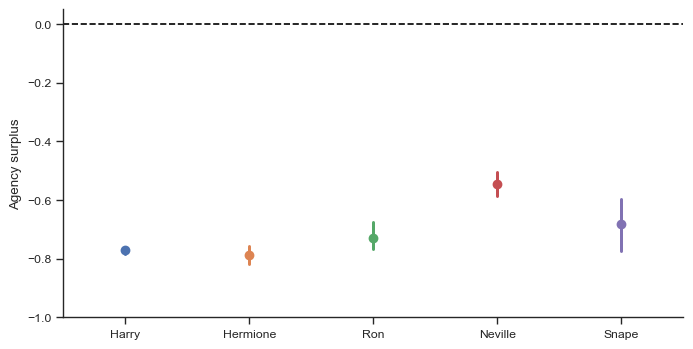

In [42]:
plt.figure(figsize=(8, 4))
sns.pointplot(data=spls_df, x='character', y='agency_surplus',
              linestyle='none', hue='character',)
plt.xlabel('')
plt.ylabel('Agency surplus')
plt.axhline(y=0, color='black', linestyle='--')
plt.ylim(-1, 0.05)
sns.despine()
plt.show()

Now let's look at the change of the agency surplus for each character in all of the 7 books:

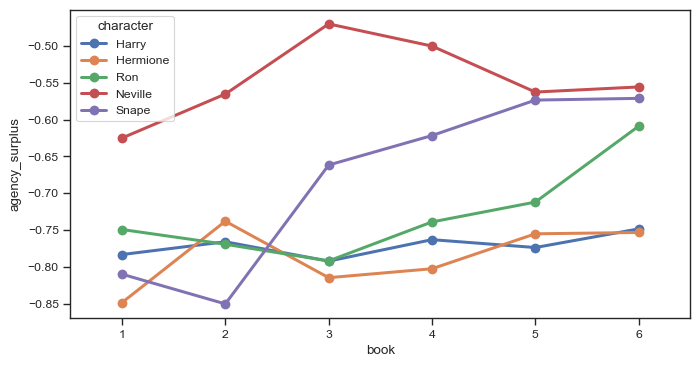

In [43]:
plt.figure(figsize=(8, 4))
sns.pointplot(data=spls_df, x='book', 
              y='agency_surplus', hue='character',)
plt.show()

What does this tell you about the books? Is there a way to update our analyses to maybe get more precise information about the agency of each character? Maybe we should exclude certain verbs, like "to say"?